<a href="https://colab.research.google.com/github/EduardoZamora03/Proyecto-samsung/blob/main/Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  REGRESIÓN 
    Filas: 117,922  |  Columnas: 79
    
Variable Y (objetivo): 'flow_duration'

  RESULTADOS DE EVALUACIÓN
  MAE  (Error Absoluto Medio):    0.296030
  MSE  (Error Cuadrático Medio):  261.051543
  RMSE (Raíz del MSE):            16.157090
  R²   (Coeficiente de det.):     0.924160

Graficas
  INTERPRETACIÓN EN CIBERSEGURIDAD

  flow_duration predice cuánto tiempo dura una conexión de red.

  ¿Por qué importa?
  ─────────────────
  • Ataques DoS mantienen conexiones largas para agotar recursos
  • Escaneos de puertos tienen conexiones muy cortas (<0.01s)
  • Comunicaciones MQTT/IoT tienen patrones predecibles

  Un modelo con R² alto (>0.90) significa que puede detectar
  conexiones anómalas (p. ej., duración = 32s cuando lo normal
  es <1s) sin necesitar etiquetas de ataque.



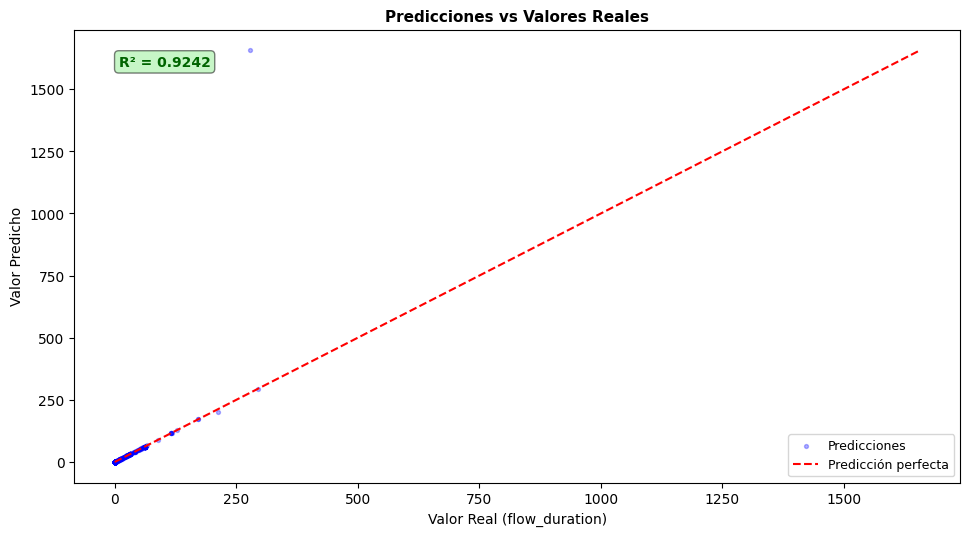

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
#warnings.filterwarnings('ignore')

print("  REGRESIÓN ")

# CARGAR DATOS
df_reg = pd.read_csv('RT_IOT2022_regresion.csv')
print(f"    Filas: {df_reg.shape[0]:,}  |  Columnas: {df_reg.shape[1]}")
# Attack_type ya fue eliminada preprocesamiento

# VARIABLE OBJETIVO Y CARACTERÍSTICAS
TARGET = 'flow_duration'

y = df_reg[TARGET]
X = df_reg.drop(TARGET, axis=1)

print(f"    \nVariable Y (objetivo): '{TARGET}'")

#  DIVIDIR DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  ENTRENAR MODELO
modelo_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1       # Usa todos los núcleos del CPU disponibles
)
modelo_reg.fit(X_train, y_train)

#  PREDECIR
predicciones_tiempo = modelo_reg.predict(X_test)

#  METRICAS
mae  = mean_absolute_error(y_test, predicciones_tiempo)
mse  = mean_squared_error(y_test, predicciones_tiempo)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, predicciones_tiempo)

print("\n  RESULTADOS DE EVALUACIÓN")
print(f"  MAE  (Error Absoluto Medio):    {mae:.6f}")
print(f"  MSE  (Error Cuadrático Medio):  {mse:.6f}")
print(f"  RMSE (Raíz del MSE):            {rmse:.6f}")
print(f"  R²   (Coeficiente de det.):     {r2:.6f}")

#  GRÁFICAS
print("\nGraficas")
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

#Predicciones vs Valores Reales
ax1 = fig.add_subplot(gs[0, 0:2])
sample_idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
y_sample    = np.array(y_test)[sample_idx]
pred_sample = predicciones_tiempo[sample_idx]

ax1.scatter(y_sample, pred_sample, alpha=0.3, s=8, color='blue', label='Predicciones')
min_val = min(y_sample.min(), pred_sample.min())
max_val = max(y_sample.max(), pred_sample.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Predicción perfecta')
ax1.set_xlabel('Valor Real (flow_duration)', fontsize=10)
ax1.set_ylabel('Valor Predicho', fontsize=10)
ax1.set_title('Predicciones vs Valores Reales', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax1.transAxes,
         fontsize=10, color='darkgreen', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

# 9. CONTEXTO DE CIBERSEGURIDAD
print("  INTERPRETACIÓN EN CIBERSEGURIDAD")
print("""
  flow_duration predice cuánto tiempo dura una conexión de red.

  • Ataques DoS mantienen conexiones largas para agotar recursos
  • Escaneos de puertos tienen conexiones muy cortas (<0.01s)
  • Comunicaciones MQTT/IoT tienen patrones predecibles

  Un modelo con R² alto (>0.90) significa que puede detectar
  conexiones anómalas (p. ej., duración = 32s cuando lo normal
  es <1s) sin necesitar etiquetas de ataque.
""")
